# Gated multimodal experiments

Linear two-stream model with per-voxel video / audio gate (`α`).

* **No PCA** on either modality — full-resolution 768-d ViT features and
  15-d MFCC features feed two independent ridge regressions.
* **No neural networks** — three closed-form solves.
* Three baselines compared throughout: **audio-only**, **video-only**,
  **gated multimodal**.
* All α / improvement maps are overlaid on the mean BOLD and masked to
  brain voxels (Otsu + temporal-variance) ∩ confident voxels
  (predictability + modality-separability).


## 1 · Imports and setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='Set2')

from sklearn.preprocessing import StandardScaler

from data_loading import (
    Sub,
    get_audio_encoding,
    get_rich_audio_encoding,
    get_video_encoding,
    _resample_to_grid,
    brain_mask,
)
from models import LinearDeltaModel
from gated_models import GatedMultimodalLinearDeltaModel
from brain_viz import show_alpha_overlay, show_signed_overlay
import utils

## 2 · Build full-resolution feature matrices

Both modalities are resampled to the same time grid and standardised
(per-modality `StandardScaler`).


In [4]:
# Audio — rich multi-family features (~144-d).
# Set USE_RICH_AUDIO=False to fall back to the legacy 15-d MFCC encoder.
USE_RICH_AUDIO = True

if USE_RICH_AUDIO:
    X_audio_raw = get_rich_audio_encoding()           # 144-d by default
else:
    X_audio_raw = get_audio_encoding(n_mfcc=15)       # legacy 15-d
print('Audio raw shape:', X_audio_raw.shape)

# Video (768-d ViT-B/16) — chunk_dir bounds peak RAM during encoding.
X_video_raw = get_video_encoding(
    video_path='src/Film stimulus.mp4',
    cache_path='src/vit_b16_features.npy',
    chunk_dir='src/vit_b16_chunks',
    chunk_size=512,
)
print('Video raw shape:', X_video_raw.shape)

# Resample both modalities to a common 25 fps × 390 s grid.
n_target = int(25.0 * 390.0)
t_target = np.linspace(0.0, 1.0, n_target)

X_video = StandardScaler().fit_transform(_resample_to_grid(X_video_raw, t_target))
X_audio = StandardScaler().fit_transform(_resample_to_grid(X_audio_raw, t_target))
print('X_video:', X_video.shape, '  X_audio:', X_audio.shape)

[Audio] 144-d features at 16821 frames (~43.1 Hz)
        composition: mfcc(40), Δmfcc(40), ΔΔmfcc(40), chroma(12), contrast(7), centroid+bandwidth+rolloff(3), rms(1), zcr(1)
Audio raw shape: (16821, 144)
[VideoEncoder] Loading cached embeddings from src/vit_b16_features.npy
Video raw shape: (9750, 768)
X_video: (9750, 768)   X_audio: (9750, 144)


## 3 · Subject and hyperparameters

In [6]:
SUB_ID  = '22'
DT      = 3       # Hemodynamic delay, seconds
COEF    = 2       # AvgPool factor on the BOLD volume
ALPHA_V = 1e4     # Ridge penalty for the (high-dim) video block
ALPHA_A = 1e4     # Ridge penalty for the (now wider) audio block;
                  # bump if you keep USE_RICH_AUDIO=True

sub = Sub(SUB_ID, data_root='/mnt/DATA2/dorin/Multimodal-fMRI-forecasting/code/src/ds003688-download')
print('BOLD volume shape:', sub.tensor.shape)

BOLD volume shape: torch.Size([40, 64, 64, 641])


## 4 · Single-modality baselines

Two reference models — one per modality — reusing the existing
`LinearDeltaModel`.  Same delay `DT` and AvgPool `COEF` as the gated
model so the train/test splits are identical and MSEs are directly
comparable.


In [7]:
audio_model = LinearDeltaModel(X_audio, sub, DT, COEF, ALPHA_A)
audio_model.fit(); audio_model.predict(); audio_model.evaluate()
print(f'[Audio-only]  MSE_test = {audio_model.MSE_test:.4e}')

video_model = LinearDeltaModel(X_video, sub, DT, COEF, ALPHA_V)
video_model.fit(); video_model.predict(); video_model.evaluate()
print(f'[Video-only]  MSE_test = {video_model.MSE_test:.4e}')

[Audio-only]  MSE_test = 2.9011e-05
[Video-only]  MSE_test = 2.8946e-05


## 5 · Gated multimodal model

Three closed-form solves: video-only ridge, audio-only ridge, then the
per-voxel scalar gate `α`.


In [8]:
gated = GatedMultimodalLinearDeltaModel(
    X_video=X_video,
    X_audio=X_audio,
    sub=sub,
    dt=DT,
    coef=COEF,
    alpha_video=ALPHA_V,
    alpha_audio=ALPHA_A,
)
gated.fit(); gated.predict(); gated.evaluate()

print(f'[Gated multimodal]  MSE_test = {gated.MSE_test:.4e}')

contrib = gated.modality_mse()
print()
print('Per-modality MSE on the test set:')
for name, mse in contrib.items():
    print(f'  {name:6s}  MSE = {mse:.4e}')

print()
print('Improvement of gated over single-modality baselines:')
delta_a = (audio_model.MSE_test - gated.MSE_test) / audio_model.MSE_test * 100
delta_v = (video_model.MSE_test - gated.MSE_test) / video_model.MSE_test * 100
print(f'  vs audio-only:  {delta_a:+.3f}%')
print(f'  vs video-only:  {delta_v:+.3f}%')

[Gated multimodal]  MSE_test = 2.8948e-05

Per-modality MSE on the test set:
  video   MSE = 2.8946e-05
  audio   MSE = 2.9011e-05
  gated   MSE = 2.8948e-05

Improvement of gated over single-modality baselines:
  vs audio-only:  +0.218%
  vs video-only:  -0.007%


## 6 · Distribution of α — how do voxels split between modalities?

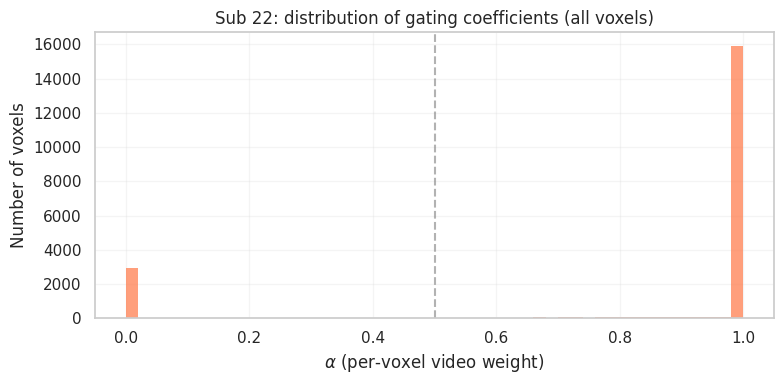

Video-dominant voxels (α > 0.6):   16886  (82.5%)
Audio-dominant voxels (α < 0.4):    3243  (15.8%)
Mixed voxels (0.4 ≤ α ≤ 0.6):        351  (1.7%)


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(gated.alpha, bins=50, color='coral', edgecolor='none', ax=ax)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$ (per-voxel video weight)')
ax.set_ylabel('Number of voxels')
ax.set_title(f'Sub {SUB_ID}: distribution of gating coefficients (all voxels)')
plt.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig(f'alpha_dist_sub{SUB_ID}.pdf', bbox_inches='tight')
plt.show()

n_video = (gated.alpha > 0.6).sum()
n_audio = (gated.alpha < 0.4).sum()
n_mixed = ((gated.alpha >= 0.4) & (gated.alpha <= 0.6)).sum()
total = gated.alpha.size

print(f'Video-dominant voxels (α > 0.6):  {n_video:>6d}  ({n_video / total * 100:.1f}%)')
print(f'Audio-dominant voxels (α < 0.4):  {n_audio:>6d}  ({n_audio / total * 100:.1f}%)')
print(f'Mixed voxels (0.4 ≤ α ≤ 0.6):     {n_mixed:>6d}  ({n_mixed / total * 100:.1f}%)')

## 7 · Build masks — anatomy + confidence

Two masks are combined for every overlay below:

* **Brain mask** (`data_loading.brain_mask`) — Otsu on the temporal-mean
  BOLD intensity to drop air, plus a 10-th percentile temporal-variance
  cut to drop static-noise voxels (skull, etc.).
* **Confidence mask** (`gated.confidence_mask`) — voxels where the
  gated model is actually informative: predictable test-set R² and
  separable video / audio predictions.


In [10]:
# Build the masks on the SAME (downsampled) grid the model uses.
brain_mask_3d = brain_mask(gated.sub._tensor.numpy(), var_quantile=0.10)

# Confidence mask defaults: top-50% R², top-70% separability.  Tighten if
# you want a more selective overlay.
conf_mask_3d = gated.confidence_volume(
    predictability_quantile=0.5,
    separability_quantile=0.3,
)

show_mask = brain_mask_3d & conf_mask_3d
print(f'Brain voxels (Otsu+var):       {brain_mask_3d.sum():>6d}  '
      f'({brain_mask_3d.mean()*100:.1f}% of volume)')
print(f'Confident voxels:              {conf_mask_3d.sum():>6d}  '
      f'({conf_mask_3d.mean()*100:.1f}% of volume)')
print(f'Brain ∩ confident (overlay):   {show_mask.sum():>6d}  '
      f'({show_mask.mean()*100:.1f}% of volume)')

# Mean BOLD for use as a grayscale underlay
mean_bold = gated.mean_bold_volume()
print('Underlay (mean BOLD) shape:', mean_bold.shape)

Brain voxels (Otsu+var):         2150  (10.5% of volume)
Confident voxels:                6937  (33.9% of volume)
Brain ∩ confident (overlay):     1115  (5.4% of volume)
Underlay (mean BOLD) shape: (20, 32, 32)


## 7.1 · α distribution restricted to confident brain voxels

The full-volume histogram in §6 is dominated by background voxels.  Re-run
it within the brain∩confident mask to see the *real* split.


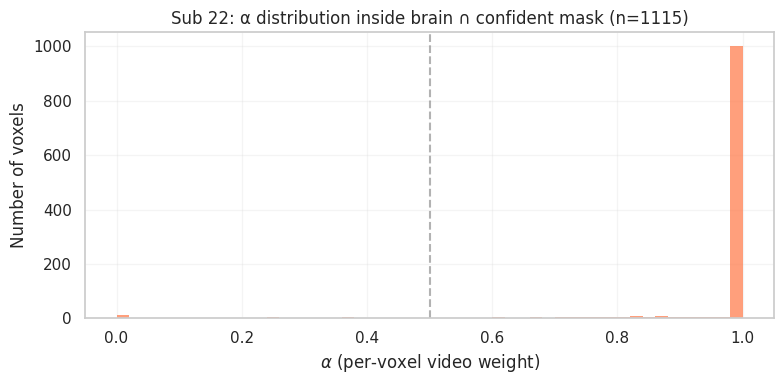

Within mask:  ⟨α⟩ = 0.963, median = 1.000
  video-dominant (α > 0.6):  97.0%
  audio-dominant (α < 0.4):  2.4%


In [11]:
alpha_in_mask = gated.alpha_volume()[show_mask]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(alpha_in_mask, bins=50, color='coral', edgecolor='none', ax=ax)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$ (per-voxel video weight)')
ax.set_ylabel('Number of voxels')
ax.set_title(
    f'Sub {SUB_ID}: α distribution inside brain ∩ confident mask '
    f'(n={alpha_in_mask.size})'
)
plt.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig(f'alpha_dist_masked_sub{SUB_ID}.pdf', bbox_inches='tight')
plt.show()

print(f'Within mask:  ⟨α⟩ = {alpha_in_mask.mean():.3f}, '
      f'median = {np.median(alpha_in_mask):.3f}')
print(f'  video-dominant (α > 0.6):  '
      f'{(alpha_in_mask > 0.6).mean()*100:.1f}%')
print(f'  audio-dominant (α < 0.4):  '
      f'{(alpha_in_mask < 0.4).mean()*100:.1f}%')

## 8 · 3-D map of α — overlaid on the BOLD anatomy

Red = video-driven (α → 1), blue = audio-driven (α → 0).  Voxels outside
the mask show only the underlay (no colour).


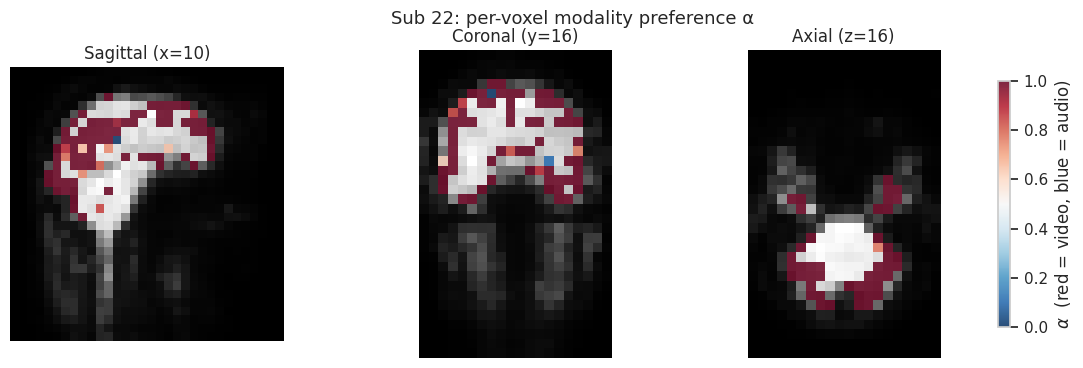

In [13]:
show_alpha_overlay(
    alpha_3d=gated.alpha_volume(),
    bold_underlay=mean_bold,
    mask_3d=show_mask,
    title=f'Sub {SUB_ID}: per-voxel modality preference α',
    save_path=None
    # save_path=f'alpha_overlay_sub{SUB_ID}.pdf',
)

## 9 · Per-voxel improvement vs audio-only

Where does the gated model beat audio-only?  Red = gated wins, blue =
audio wins.


Within mask: gated beats audio in 545/1115 voxels (48.9%)


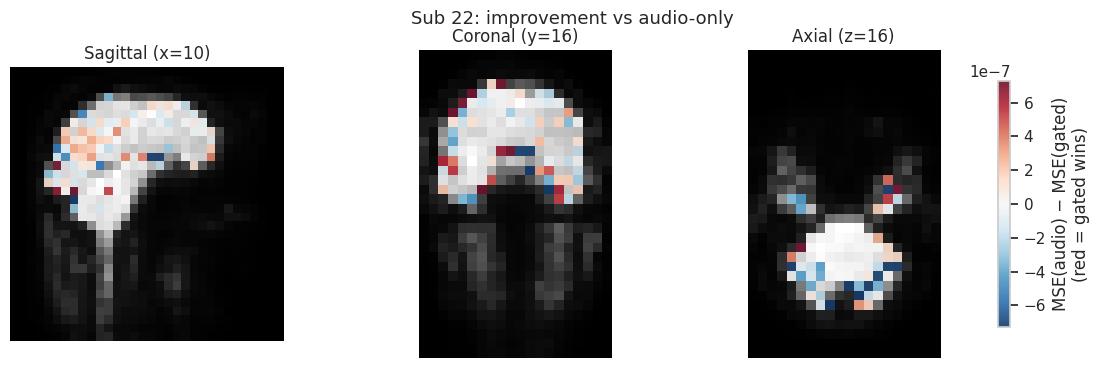

In [14]:
true_test = np.delete(gated.Y_test, 0, 1)
err_audio = np.mean(
    (audio_model.Y_test_predicted - np.delete(audio_model.Y_test, 0, 1)) ** 2,
    axis=1,
)
err_gated = np.mean((gated.Y_test_predicted - true_test) ** 2, axis=1)
imp_vs_audio = err_audio - err_gated

n_win = (imp_vs_audio[show_mask.ravel()] > 0).sum()
n_total = int(show_mask.sum())
print(f'Within mask: gated beats audio in {n_win}/{n_total} voxels '
      f'({n_win / max(n_total, 1) * 100:.1f}%)')

show_signed_overlay(
    values_3d=imp_vs_audio.reshape(gated._d1, gated._d2, gated._d3),
    bold_underlay=mean_bold,
    mask_3d=show_mask,
    title=f'Sub {SUB_ID}: improvement vs audio-only',
    cbar_label='MSE(audio) − MSE(gated)\n(red = gated wins)',
    save_path=None,
    # save_path=f'improvement_vs_audio_sub{SUB_ID}.pdf',
)

## 10 · Per-voxel improvement vs video-only

The mirror analysis: where does the gated model beat the video-only
baseline?  Red = gated wins (presumably auditory regions), blue =
video-only is already as good as gated.


Within mask: gated beats video-only in 72/1115 voxels (6.5%)


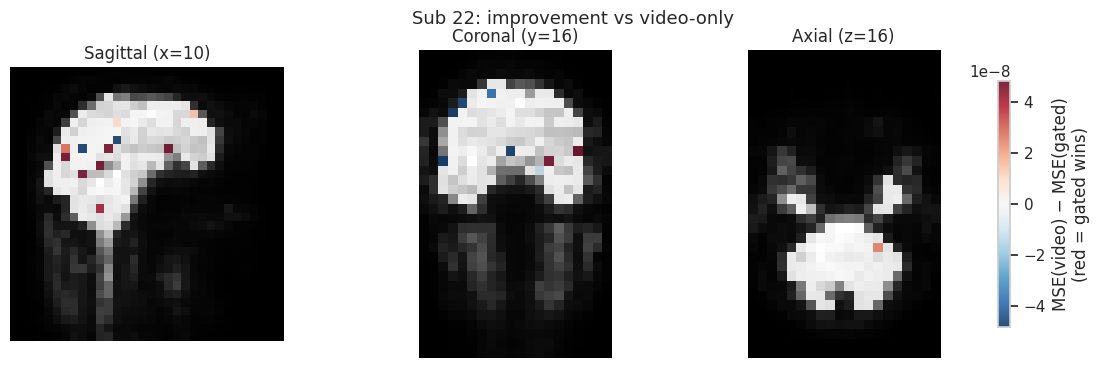

In [15]:
err_video = np.mean(
    (video_model.Y_test_predicted - np.delete(video_model.Y_test, 0, 1)) ** 2,
    axis=1,
)
imp_vs_video = err_video - err_gated

n_win = (imp_vs_video[show_mask.ravel()] > 0).sum()
print(f'Within mask: gated beats video-only in {n_win}/{n_total} voxels '
      f'({n_win / max(n_total, 1) * 100:.1f}%)')

show_signed_overlay(
    values_3d=imp_vs_video.reshape(gated._d1, gated._d2, gated._d3),
    bold_underlay=mean_bold,
    mask_3d=show_mask,
    title=f'Sub {SUB_ID}: improvement vs video-only',
    cbar_label='MSE(video) − MSE(gated)\n(red = gated wins)',
    save_path=None,
    # save_path=f'improvement_vs_video_sub{SUB_ID}.pdf',
)

## 11 · Δt sweep — audio / video / gated

Verifies that the relative ordering of the three models is robust across
hemodynamic delays.


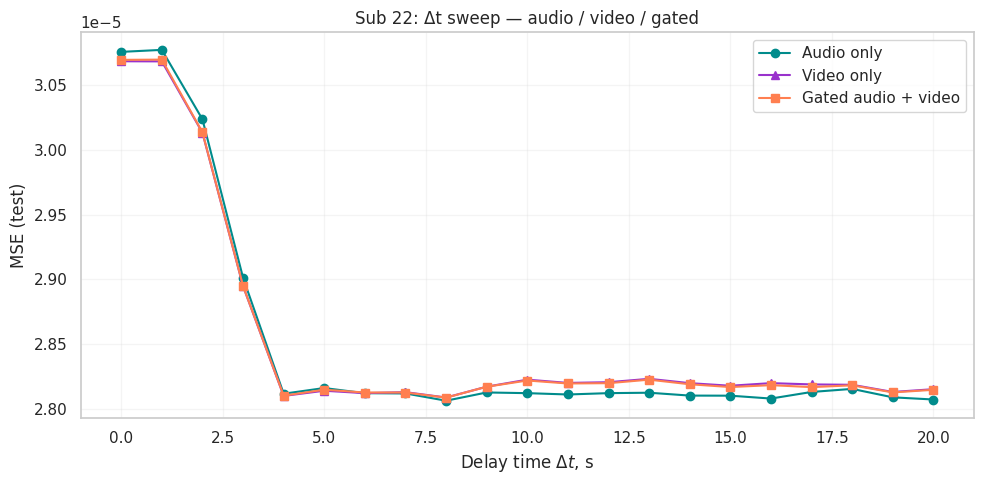

Best Δt audio:  8s  (MSE=2.8060e-05)
Best Δt video:  8s  (MSE=2.8085e-05)
Best Δt gated:  8s  (MSE=2.8084e-05)


In [16]:
t_vals = np.arange(0, 21, 1)
mse_audio, mse_video, mse_gated = [], [], []

for dt_val in t_vals:
    m_a = LinearDeltaModel(X_audio, sub, dt_val, COEF, ALPHA_A)
    m_a.fit(); m_a.predict(); m_a.evaluate()
    mse_audio.append(m_a.MSE_test)

    m_v = LinearDeltaModel(X_video, sub, dt_val, COEF, ALPHA_V)
    m_v.fit(); m_v.predict(); m_v.evaluate()
    mse_video.append(m_v.MSE_test)

    m_g = GatedMultimodalLinearDeltaModel(
        X_video=X_video, X_audio=X_audio,
        sub=sub, dt=dt_val, coef=COEF,
        alpha_video=ALPHA_V, alpha_audio=ALPHA_A,
    )
    m_g.fit(); m_g.predict(); m_g.evaluate()
    mse_gated.append(m_g.MSE_test)

plt.figure(figsize=(10, 5))
plt.plot(t_vals, mse_audio, marker='o', color='darkcyan', label='Audio only')
plt.plot(t_vals, mse_video, marker='^', color='darkorchid', label='Video only')
plt.plot(t_vals, mse_gated, marker='s', color='coral',     label='Gated audio + video')
plt.xlabel(r'Delay time $\Delta t$, s')
plt.ylabel('MSE (test)')
plt.title(f'Sub {SUB_ID}: Δt sweep — audio / video / gated')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
# plt.savefig(f'mse_dt_gated_sub{SUB_ID}.pdf', bbox_inches='tight')
plt.show()

best_dt_a = t_vals[int(np.argmin(mse_audio))]
best_dt_v = t_vals[int(np.argmin(mse_video))]
best_dt_g = t_vals[int(np.argmin(mse_gated))]
print(f'Best Δt audio:  {best_dt_a}s  (MSE={min(mse_audio):.4e})')
print(f'Best Δt video:  {best_dt_v}s  (MSE={min(mse_video):.4e})')
print(f'Best Δt gated:  {best_dt_g}s  (MSE={min(mse_gated):.4e})')

## 12 · Multi-subject comparison — audio / video / gated

Sub 07:  audio=2.4923e-05  video=2.5032e-05  gated=2.5019e-05  (Δ vs A=-0.39%, Δ vs V=+0.05%, ⟨α⟩=0.829)
Sub 22:  audio=2.9011e-05  video=2.8946e-05  gated=2.8948e-05  (Δ vs A=+0.22%, Δ vs V=-0.01%, ⟨α⟩=0.828)
Sub 31:  audio=3.2516e-05  video=3.2473e-05  gated=3.2491e-05  (Δ vs A=+0.08%, Δ vs V=-0.05%, ⟨α⟩=0.837)


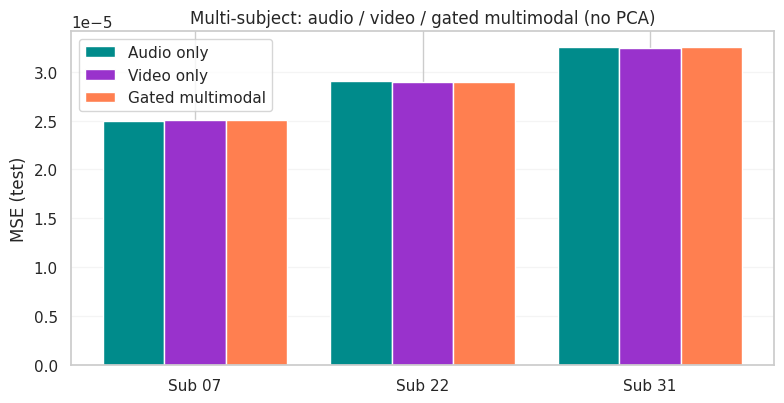

In [19]:
subjects = ['07', '22', '31']
results = {}

for sid in subjects:
    s = Sub(sid, data_root='/mnt/DATA2/dorin/Multimodal-fMRI-forecasting/code/src/ds003688-download')

    m_a = LinearDeltaModel(X_audio, s, DT, COEF, ALPHA_A)
    m_a.fit(); m_a.predict(); m_a.evaluate()

    m_v = LinearDeltaModel(X_video, s, DT, COEF, ALPHA_V)
    m_v.fit(); m_v.predict(); m_v.evaluate()

    m_g = GatedMultimodalLinearDeltaModel(
        X_video=X_video, X_audio=X_audio,
        sub=s, dt=DT, coef=COEF,
        alpha_video=ALPHA_V, alpha_audio=ALPHA_A,
    )
    m_g.fit(); m_g.predict(); m_g.evaluate()

    delta_a = (m_a.MSE_test - m_g.MSE_test) / m_a.MSE_test * 100
    delta_v = (m_v.MSE_test - m_g.MSE_test) / m_v.MSE_test * 100
    results[sid] = {
        'audio':         m_a.MSE_test,
        'video':         m_v.MSE_test,
        'gated':         m_g.MSE_test,
        'delta_vs_a':    delta_a,
        'delta_vs_v':    delta_v,
        'alpha_mean':    float(m_g.alpha.mean()),
    }
    print(
        f'Sub {sid}:  audio={m_a.MSE_test:.4e}  video={m_v.MSE_test:.4e}  '
        f'gated={m_g.MSE_test:.4e}  '
        f'(Δ vs A={delta_a:+.2f}%, Δ vs V={delta_v:+.2f}%, '
        f'⟨α⟩={m_g.alpha.mean():.3f})'
    )

# Three-bar group plot
x = np.arange(len(subjects))
w = 0.27
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x - w, [results[s]['audio'] for s in subjects], w,
       color='darkcyan',  label='Audio only')
ax.bar(x,     [results[s]['video'] for s in subjects], w,
       color='darkorchid', label='Video only')
ax.bar(x + w, [results[s]['gated'] for s in subjects], w,
       color='coral',     label='Gated multimodal')
ax.set_xticks(x)
ax.set_xticklabels([f'Sub {s}' for s in subjects])
ax.set_ylabel('MSE (test)')
ax.set_title('Multi-subject: audio / video / gated multimodal (no PCA)')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
# plt.savefig('mse_subjects_gated.pdf', bbox_inches='tight')
plt.show()

## 13 · Per-subject α maps (overlaid)

Side-by-side comparison of the gating maps for each subject, all on
their own brain anatomy and within their own confidence mask.


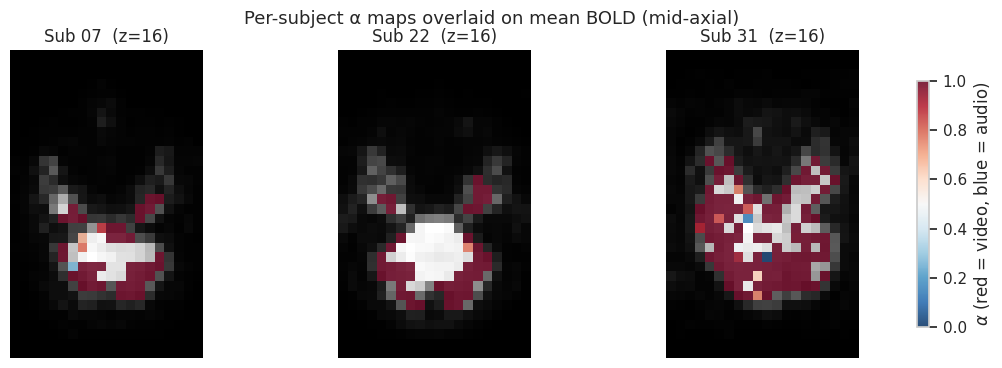

In [21]:
fig, axes = plt.subplots(1, len(subjects), figsize=(5 * len(subjects), 4))
if len(subjects) == 1:
    axes = [axes]

for ax, sid in zip(axes, subjects):
    s = Sub(sid, data_root='/mnt/DATA2/dorin/Multimodal-fMRI-forecasting/code/src/ds003688-download')

    m_g = GatedMultimodalLinearDeltaModel(
        X_video=X_video, X_audio=X_audio,
        sub=s, dt=DT, coef=COEF,
        alpha_video=ALPHA_V, alpha_audio=ALPHA_A,
    )
    m_g.fit(); m_g.predict()

    bm = brain_mask(m_g.sub._tensor.numpy(), var_quantile=0.10)
    cm = m_g.confidence_volume(
        predictability_quantile=0.5, separability_quantile=0.3,
    )
    mask = bm & cm

    underlay = m_g.mean_bold_volume()
    a3d = m_g.alpha_volume()
    sl = a3d.shape[2] // 2

    ax.imshow(underlay[:, :, sl].T, cmap='gray', origin='lower')
    masked = np.where(mask[:, :, sl], a3d[:, :, sl], np.nan).T
    cmap = plt.get_cmap('RdBu_r').copy(); cmap.set_bad(alpha=0.0)
    im = ax.imshow(masked, cmap=cmap, origin='lower',
                   vmin=0, vmax=1, alpha=0.85)
    ax.set_title(f'Sub {sid}  (z={sl})')
    ax.axis('off')

fig.colorbar(im, ax=axes,
             label=r'$\alpha$ (red = video, blue = audio)', shrink=0.8)
fig.suptitle('Per-subject α maps overlaid on mean BOLD (mid-axial)',
             fontsize=13)
# plt.savefig('alpha_grid_subjects.pdf', bbox_inches='tight')
plt.show()